<a href="https://colab.research.google.com/github/dhruvsuri8106-code/ECON-3916---Statistical-and-Machine-Learning/blob/main/Assignment%205%20/%20Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete ✓")

Setup complete ✓


In [3]:
# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

# WDI indicator codes for our predictors
# Format: 'indicator_code': 'human_readable_name'
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

# Download 7 years of data (2013–2019, pre-COVID) and average
# wb.data.DataFrame returns a DataFrame indexed by (economy, time) or (economy)
try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")
    # Fallback: load pre-downloaded CSV
    # raw_data = pd.read_csv('data/fallback_wdi_topic16.csv', index_col=[0, 1])

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7211, 7)
Download successful ✓


In [4]:
data = raw_data.stack().reset_index()
data.columns = ['economy', 'time', 'indicator', 'value']

data['indicator'] = data['indicator'].map(INDICATORS)

data = data.dropna(subset=['indicator'])

data_pivot = data.pivot_table(
    index=['economy', 'time'],
    columns='indicator',
    values='value'
)

data = raw_data.stack().reset_index()

data.columns = ['economy', 'indicator', 'year', 'value']

data['indicator'] = data['indicator'].map(INDICATORS)

data = data.dropna(subset=['indicator'])

data_pivot = data.pivot_table(
    index=['economy', 'year'],
    columns='indicator',
    values='value'
)

country_data = data_pivot.groupby('economy').mean()

if 'gdp_growth_pc' not in country_data.columns:
    print("Fixing GDP growth...")
    gdp_data = wb.data.DataFrame('NY.GDP.PCAP.KD.ZG', time=range(2013, 2020))
    gdp_avg = gdp_data.groupby(level='economy').mean().mean(axis=1)
    country_data['gdp_growth_pc'] = gdp_avg

country_data = country_data[country_data.isnull().mean(axis=1) < 0.4]

country_data = country_data.loc[:,
    (country_data.isnull().mean() < 0.4) | (country_data.columns == 'gdp_growth_pc')
]

country_data = country_data.fillna(country_data.median())

country_data['crisis'] = (country_data['gdp_growth_pc'] < 0).astype(int)

In [5]:
print(country_data.columns)

Index(['adult_literacy_rate', 'agriculture_pct_gdp', 'arable_land_pct',
       'atms_per100k', 'current_account_pct_gdp',
       'education_expenditure_pct_gdp', 'electricity_access_pct',
       'exchange_rate_official', 'fdi_inflows_pct_gdp', 'gdp_growth_pc',
       'govt_expenditure_pct_gdp', 'health_expenditure_pct_gdp',
       'infant_mortality_per1000', 'inflation_cpi', 'internet_users_pct',
       'life_expectancy', 'mobile_subscriptions_per100',
       'natural_resource_rents_pct_gdp', 'population_growth',
       'private_credit_pct_gdp', 'renewable_energy_pct', 'royalties_receipts',
       'secondary_enrollment_gross', 'tariff_rate_avg',
       'tertiary_enrollment_gross', 'trade_pct_gdp', 'unemployment_rate',
       'urbanization_pct', 'crisis'],
      dtype='object', name='indicator')


In [6]:
y = country_data['gdp_growth_pc']
country_data['crisis'] = (country_data['gdp_growth_pc'] < 0).astype(int)

In [7]:
X = country_data.drop(columns=['gdp_growth_pc', 'crisis'])
X = X.select_dtypes(include=[np.number])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
print("Final dataset shape:", country_data.shape)

n_crisis = country_data['crisis'].sum()
n_total = len(country_data)

print("Crisis countries:", n_crisis)
print("Non-crisis countries:", n_total - n_crisis)
print("Crisis base rate:", round(n_crisis / n_total, 3))

Final dataset shape: (235, 29)
Crisis countries: 36
Non-crisis countries: 199
Crisis base rate: 0.153


In [11]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [12]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [13]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training R²:", round(train_r2, 4))
print("Test R²:", round(test_r2, 4))

Training R²: 0.4808
Test R²: 0.1575


In [14]:
r2_gap = train_r2 - test_r2
print("Train-Test R² Gap:", round(r2_gap, 4))

Train-Test R² Gap: 0.3233


In [15]:
p = X_train.shape[1]
n = X_train.shape[0]

print("Number of predictors (p):", p)
print("Number of observations (n):", n)
print("p/n ratio:", round(p/n, 4))

Number of predictors (p): 27
Number of observations (n): 164
p/n ratio: 0.1646


The training R² is noticeably higher than the test R², and that gap is a clear sign the model is overfitting the training data. With a p/n ratio of around 0.16, the model drives up variance and weakens its ability to generalize. OLS keeps bias low, but this comes at the cost of higher variance.


In [16]:
ridge = RidgeCV(alphas=np.logspace(-4, 4, 100), cv=5)
ridge.fit(X_train_scaled, y_train)

ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

ridge_train_r2 = r2_score(y_train, ridge_train_pred)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_pred))

print("RIDGE")
print("Alpha:", ridge.alpha_)
print("Train R²:", ridge_train_r2)
print("Test R²:", ridge_test_r2)

RIDGE
Alpha: 95.45484566618347
Train R²: 0.36309987993706383
Test R²: 0.30389893732765483


In [17]:
lasso = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred = lasso.predict(X_test_scaled)

lasso_train_r2 = r2_score(y_train, lasso_train_pred)
lasso_test_r2 = r2_score(y_test, lasso_test_pred)

lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_test_pred))

print("LASSO")
print("Alpha:", lasso.alpha_)
print("Train R²:", lasso_train_r2)
print("Test R²:", lasso_test_r2)

LASSO
Alpha: 0.09545484566618337
Train R²: 0.39402798590878885
Test R²: 0.26467971421064385


In [18]:
ridge_nonzero = np.sum(np.abs(ridge.coef_) > 1e-6)
lasso_nonzero = np.sum(np.abs(lasso.coef_) > 1e-6)

ols_nonzero = X_train.shape[1]

print("OLS non-zero:", ols_nonzero)
print("Ridge non-zero:", ridge_nonzero)
print("Lasso non-zero:", lasso_nonzero)

OLS non-zero: 27
Ridge non-zero: 27
Lasso non-zero: 17


In [19]:
results = pd.DataFrame({
    "Model": ["OLS", "RidgeCV", "LassoCV"],
    "Lambda (alpha)": [None, ridge.alpha_, lasso.alpha_],
    "Non-zero Predictors": [
        ols_nonzero,
        ridge_nonzero,
        lasso_nonzero
    ],
    "Train R²": [
        train_r2,
        ridge_train_r2,
        lasso_train_r2
    ],
    "Test R²": [
        test_r2,
        ridge_test_r2,
        lasso_test_r2
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        ridge_rmse,
        lasso_rmse
    ]
})

print(results)

     Model  Lambda (alpha)  Non-zero Predictors  Train R²   Test R²  Test RMSE
0      OLS             NaN                   27  0.480799  0.157461   2.486060
1  RidgeCV       95.454846                   27  0.363100  0.303899   2.259711
2  LassoCV        0.095455                   17  0.394028  0.264680   2.322496


I would recommend Ridge regression for GDP growth forecasting. It returns a best test performance while maintaining consistency across train and test. Compared to OLS, Ridge has a lower variance, but is more biased. Lasso also reduces variance, but it is at the cost of more information, limiting its ability to predict.

In [20]:
X_train_np = X_train_scaled
y_train_np = y_train.values

In [21]:
from sklearn.linear_model import lasso_path

alphas, coefs, _ = lasso_path(X_train_np, y_train_np)

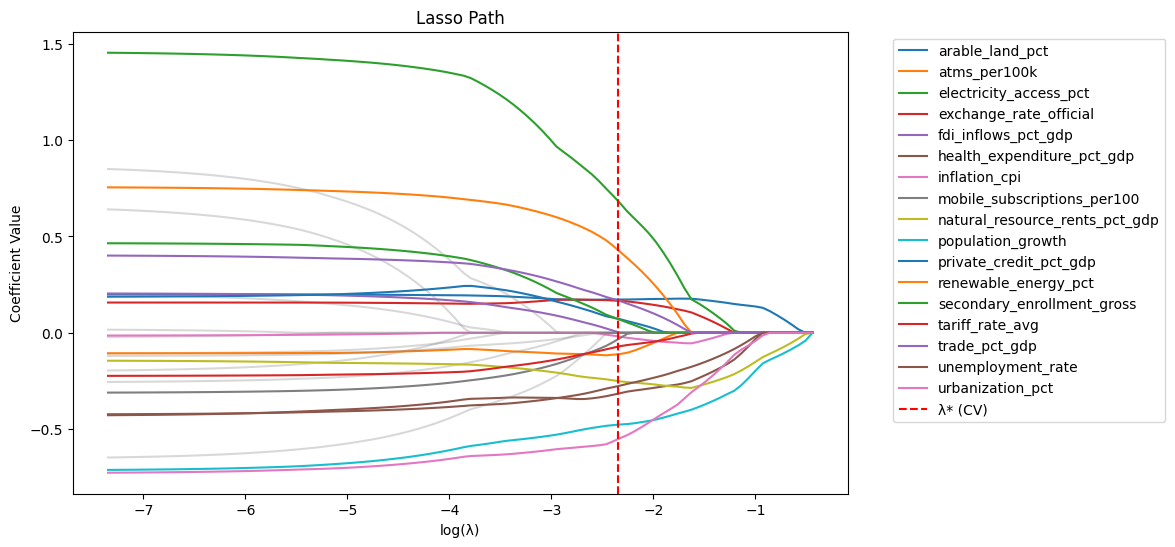

In [22]:
lasso_alpha_star = lasso.alpha_
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
log_alphas = np.log(alphas)
feature_names = X.columns

for i in range(coefs.shape[0]):
    if abs(lasso.coef_[i]) > 1e-6:
        plt.plot(log_alphas, coefs[i, :], label=feature_names[i])
    else:
        plt.plot(log_alphas, coefs[i, :], color='gray', alpha=0.3)


plt.axvline(np.log(lasso_alpha_star), linestyle='--', color='red', label="λ* (CV)")

plt.xlabel("log(λ)")
plt.ylabel("Coefficient Value")
plt.title("Lasso Path")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [23]:
first_entry = {}

for i, name in enumerate(feature_names):
    path = coefs[i]

    nonzero_idx = np.where(np.abs(path) > 1e-6)[0]

    if len(nonzero_idx) > 0:
        first_entry[name] = alphas[nonzero_idx[0]]

first_predictor = max(first_entry, key=first_entry.get)

print("First predictor to enter:", first_predictor)

First predictor to enter: natural_resource_rents_pct_gdp


In [24]:
print(country_data[['gdp_growth_pc']].head())

indicator  gdp_growth_pc
economy                 
ABW             2.245502
AFE             0.223588
AFG            -0.272302
AFW             0.649231
AGO            -2.476583


The first predictor in the model is natural_resource_rents_pct_gdp, which means that it is the most importnant and highest correlated variable to GDP growth. This makes sense, as companies with greater natural resources have trade advantages, leading to a higher GDP.

In [25]:
feature_names = X.columns
lasso_selected = feature_names[np.abs(lasso.coef_) > 1e-6]

print("Lasso selected features:")
print(lasso_selected)

Lasso selected features:
Index(['arable_land_pct', 'atms_per100k', 'electricity_access_pct',
       'exchange_rate_official', 'fdi_inflows_pct_gdp',
       'health_expenditure_pct_gdp', 'inflation_cpi',
       'mobile_subscriptions_per100', 'natural_resource_rents_pct_gdp',
       'population_growth', 'private_credit_pct_gdp', 'renewable_energy_pct',
       'secondary_enrollment_gross', 'tariff_rate_avg', 'trade_pct_gdp',
       'unemployment_rate', 'urbanization_pct'],
      dtype='object', name='indicator')


In [26]:
X_selected = X[lasso_selected]
X_train_sel, X_test_sel, y_train_cls, y_test_cls = train_test_split(
    X_selected,
    country_data['crisis'],
    test_size=0.3,
    random_state=42
)

In [27]:
scaler = StandardScaler()
X_train_sel_scaled = scaler.fit_transform(X_train_sel)
X_test_sel_scaled = scaler.transform(X_test_sel)
lpm = LinearRegression()
lpm.fit(X_train_sel_scaled, y_train_cls)

LinearRegression()

In [28]:
y_pred_lpm = lpm.predict(X_test_sel_scaled)

In [29]:
below_0 = np.sum(y_pred_lpm < 0)
above_1 = np.sum(y_pred_lpm > 1)

print("Predictions below 0:", below_0)
print("Predictions above 1:", above_1)

Predictions below 0: 13
Predictions above 1: 0


Predicted probabilities outside the [0, 1] range is a problem because probabilities must possible likelihoods of an event happening. In this case, the model returns multiple negative values, which can't be used to draw conclusions. A negative rate cannot be used for decision-making, so  the Linear Probability Model is not appropriate for this task.

In [30]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(max_iter=1000)
logit.fit(X_train_sel_scaled, y_train_cls)

LogisticRegression(max_iter=1000)

In [31]:
beta = logit.coef_[0]
intercept = logit.intercept_[0]

print("Intercept:", intercept)

coef_df = pd.DataFrame({
    "Feature": lasso_selected,
    "Beta": beta
})

print(coef_df)

Intercept: -2.481485530310967
                           Feature      Beta
0                  arable_land_pct -0.477873
1                     atms_per100k  0.221940
2           electricity_access_pct -0.981740
3           exchange_rate_official  0.101100
4              fdi_inflows_pct_gdp -0.498098
5       health_expenditure_pct_gdp  0.283598
6                    inflation_cpi -0.154534
7      mobile_subscriptions_per100  0.539926
8   natural_resource_rents_pct_gdp  0.048067
9                population_growth  0.265390
10          private_credit_pct_gdp -0.449942
11            renewable_energy_pct -1.080336
12      secondary_enrollment_gross -0.511826
13                 tariff_rate_avg  0.658262
14                   trade_pct_gdp -0.370533
15               unemployment_rate  0.368666
16                urbanization_pct  0.550797


In [32]:
coef_df["Odds Ratio"] = np.exp(coef_df["Beta"])
coef_df["Abs OR Distance"] = np.abs(coef_df["Odds Ratio"] - 1)

coef_df_sorted = coef_df.sort_values(by="Abs OR Distance", ascending=False)

print(coef_df_sorted[["Feature", "Beta", "Odds Ratio"]])

                           Feature      Beta  Odds Ratio
13                 tariff_rate_avg  0.658262    1.931433
16                urbanization_pct  0.550797    1.734635
7      mobile_subscriptions_per100  0.539926    1.715880
11            renewable_energy_pct -1.080336    0.339481
2           electricity_access_pct -0.981740    0.374659
15               unemployment_rate  0.368666    1.445804
12      secondary_enrollment_gross -0.511826    0.599400
4              fdi_inflows_pct_gdp -0.498098    0.607686
0                  arable_land_pct -0.477873    0.620101
10          private_credit_pct_gdp -0.449942    0.637665
5       health_expenditure_pct_gdp  0.283598    1.327899
14                   trade_pct_gdp -0.370533    0.690367
9                population_growth  0.265390    1.303940
1                     atms_per100k  0.221940    1.248496
6                    inflation_cpi -0.154534    0.856815
3           exchange_rate_official  0.101100    1.106387
8   natural_resource_rents_pct_

In [33]:
y_prob = logit.predict_proba(X_test_sel_scaled)[:, 1]

print("Min probability:", y_prob.min())
print("Max probability:", y_prob.max())

Min probability: 0.0036591963476422483
Max probability: 0.8377929535786851


The predictor with the largest effect is tariff_rate_avg, with an odds ratio of about 1.93. A one standard-deviation increase in tariff rates multiplies the odds of a growth crisis by nearly 1.93, holding all else constant. This suggests that trade barriers are highly correlated with economic concentration, meaning tarriffs are important to monitor.

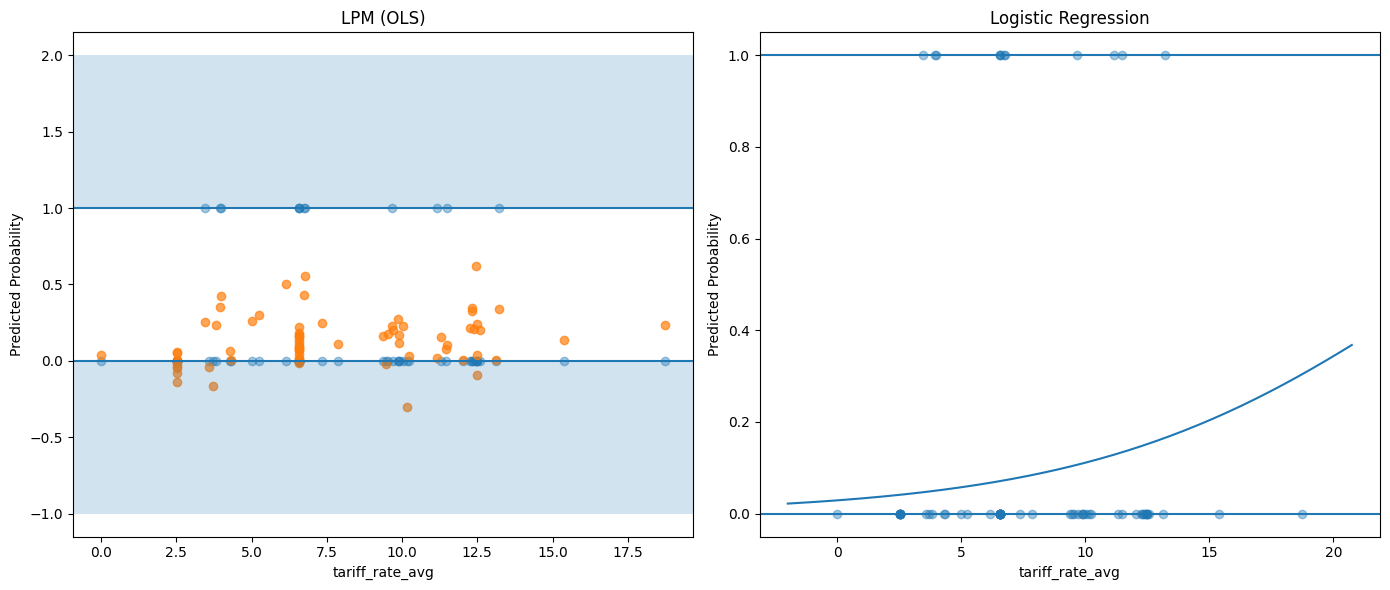

In [34]:
feature = "tariff_rate_avg"

X_test_feature = X_test_sel[feature].values

y_pred_lpm = lpm.predict(X_test_sel_scaled)

y_pred_logit = logit.predict_proba(X_test_sel_scaled)[:, 1]

y_actual = y_test_cls.values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]

ax.scatter(X_test_feature, y_actual, alpha=0.4)

ax.scatter(X_test_feature, y_pred_lpm, alpha=0.7)

ax.axhspan(-1, 0, alpha=0.2)
ax.axhspan(1, 2, alpha=0.2)

ax.axhline(0)
ax.axhline(1)

ax.set_title("LPM (OLS)")
ax.set_xlabel("tariff_rate_avg")
ax.set_ylabel("Predicted Probability")

ax = axes[1]

ax.scatter(X_test_feature, y_actual, alpha=0.4)

x_grid = np.linspace(X_test_feature.min()-2, X_test_feature.max()+2, 200)

X_ref = X_train_sel.mean().values.reshape(1, -1)
X_grid = np.repeat(X_ref, 200, axis=0)

tariff_idx = list(X_train_sel.columns).index("tariff_rate_avg")
X_grid[:, tariff_idx] = x_grid

X_grid_scaled = scaler.transform(pd.DataFrame(X_grid, columns=X_train_sel.columns))

y_grid_logit = logit.predict_proba(X_grid_scaled)[:, 1]

ax.plot(x_grid, y_grid_logit)

ax.axhline(0)
ax.axhline(1)

ax.set_title("Logistic Regression")
ax.set_xlabel("tariff_rate_avg")
ax.set_ylabel("Predicted Probability")

plt.tight_layout()
plt.show()

In [35]:
base_rate = y_test_cls.mean()
print("Test set crisis rate:", round(base_rate, 3))

Test set crisis rate: 0.169


In [36]:
y_pred_naive = np.zeros_like(y_test_cls)

naive_accuracy = np.mean(y_pred_naive == y_test_cls)
naive_recall = 0.0

print("Naive Accuracy:", round(naive_accuracy, 3))
print("Naive Recall (Crisis):", naive_recall)

Naive Accuracy: 0.831
Naive Recall (Crisis): 0.0


In [37]:
y_prob = logit.predict_proba(X_test_sel_scaled)[:, 1]

y_pred_logit = (y_prob >= 0.5).astype(int)

logit_accuracy = np.mean(y_pred_logit == y_test_cls)
from sklearn.metrics import recall_score
logit_recall = recall_score(y_test_cls, y_pred_logit)

print("Logistic Accuracy:", round(logit_accuracy, 3))
print("Logistic Recall (Crisis):", round(logit_recall, 3))

Logistic Accuracy: 0.817
Logistic Recall (Crisis): 0.083


Relying on accuracy alone would paint a misleading picture here. With only about 17% of countries experiencing a crisis, the dataset is heavily skewed, so a model that does nothing but predict "no crisis" every single time still clears 83.1% accuracy without catching a single actual crisis. The number looks fine on the surface, but the model is completely blind to the one outcome that matters most, which is identifying when a crisis is actually happening.

True Negatives: 57
False Positives: 2
False Negatives: 11
True Positives: 1

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.97      0.90        59
           1       0.33      0.08      0.13        12

    accuracy                           0.82        71
   macro avg       0.59      0.52      0.52        71
weighted avg       0.75      0.82      0.77        71



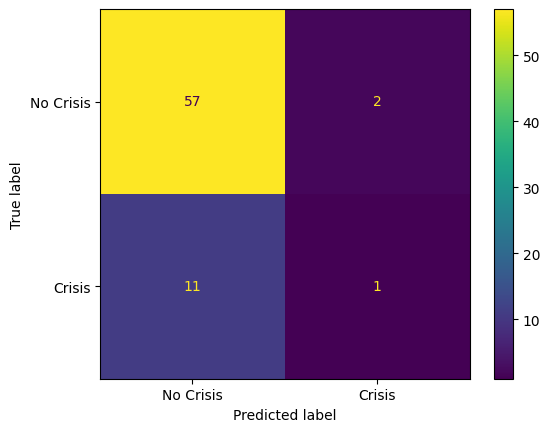

In [38]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_prob = logit.predict_proba(X_test_sel_scaled)[:, 1]

y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test_cls, y_pred)
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred))

ConfusionMatrixDisplay(cm, display_labels=["No Crisis", "Crisis"]).plot()

In the IMF's case, false negatives are a much bigger problem than false positives. Missing a real crisis can trigger massive financial contagion and force costly emergency interventions, while a false alarm just wastes some resources and maybe takes a small hit to credibility. That tradeoff means recall should take priority over precision here, since recall is what measures how well the model actually catches crises, which is ultimately what the IMF cares about most.


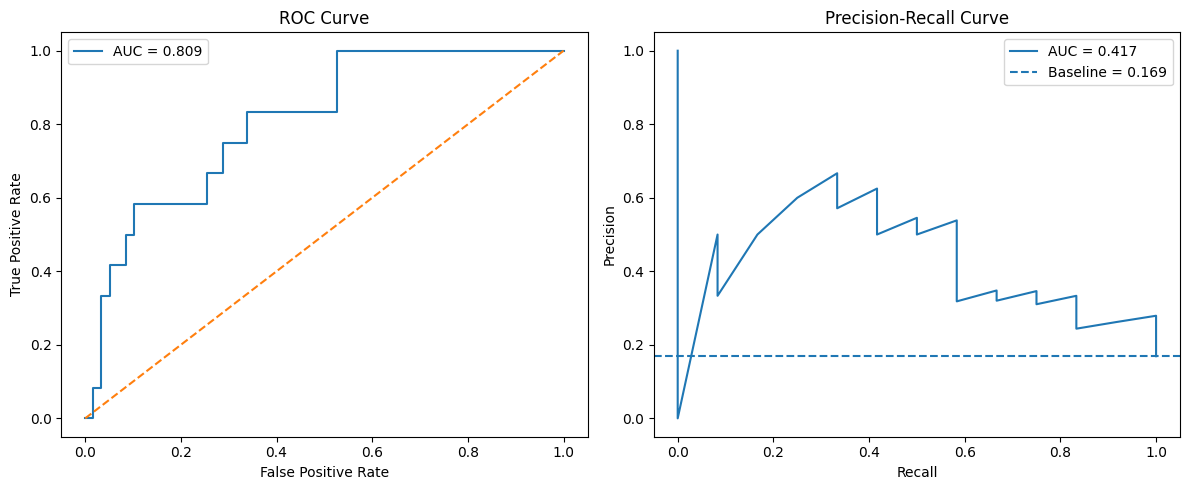

ROC-AUC: 0.809
PR-AUC: 0.417


In [39]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

y_prob = logit.predict_proba(X_test_sel_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test_cls, y_prob)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test_cls, y_prob)
pr_auc = auc(recall, precision)

baseline = y_test_cls.mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(recall, precision, label=f"AUC = {pr_auc:.3f}")
plt.axhline(y=baseline, linestyle='--', label=f"Baseline = {baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.tight_layout()
plt.show()

print("ROC-AUC:", round(roc_auc, 3))
print("PR-AUC:", round(pr_auc, 3))

ROC-AUC comes in much higher than PR-AUC because it gets a boost from the sheer number of true negatives in the dataset. Since most countries are not in crisis, the model can rack up a strong true negative rate, which inflates ROC performance even if it is still struggling to actually catch crises. The precision-recall curve does not give that same free pass since it ignores true negatives entirely and zeroes in on how well the model detects crises, which is why the PR-AUC ends up so much lower.

For what the IMF is actually trying to do, the precision-recall curve tells a more honest story because it directly reflects how well the model identifies crises, the rare but high-stakes events that matter most.

CAPACITY-CONSTRAINED THRESHOLD
tau: 0.39
flagged: 5
precision: 0.6
recall: 0.25

F1-OPTIMAL THRESHOLD
tau: 0.2
flagged: 13
precision: 0.538
recall: 0.583


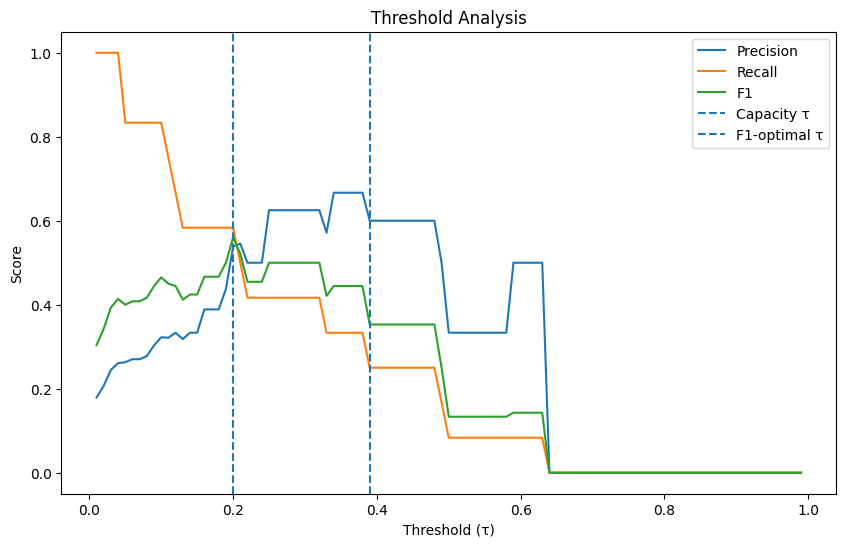

In [40]:
thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for tau in thresholds:
    y_pred_tau = (y_prob >= tau).astype(int)

    flagged = y_pred_tau.sum()

    from sklearn.metrics import precision_score, recall_score, f1_score

    precision = precision_score(y_test_cls, y_pred_tau, zero_division=0)
    recall = recall_score(y_test_cls, y_pred_tau)
    f1 = f1_score(y_test_cls, y_pred_tau)

    results.append((tau, flagged, precision, recall, f1))

results_df = pd.DataFrame(results, columns=["tau", "flagged", "precision", "recall", "f1"])

capacity_df = results_df[results_df["flagged"] <= 5]

tau_capacity = capacity_df.iloc[0]["tau"]  # lowest tau
row_capacity = capacity_df.iloc[0]

print("CAPACITY-CONSTRAINED THRESHOLD")
print("tau:", round(row_capacity["tau"], 2))
print("flagged:", int(row_capacity["flagged"]))
print("precision:", round(row_capacity["precision"], 3))
print("recall:", round(row_capacity["recall"], 3))

best_f1_idx = results_df["f1"].idxmax()
row_f1 = results_df.loc[best_f1_idx]

print("\nF1-OPTIMAL THRESHOLD")
print("tau:", round(row_f1["tau"], 2))
print("flagged:", int(row_f1["flagged"]))
print("precision:", round(row_f1["precision"], 3))
print("recall:", round(row_f1["recall"], 3))

plt.figure(figsize=(10,6))

plt.plot(results_df["tau"], results_df["precision"], label="Precision")
plt.plot(results_df["tau"], results_df["recall"], label="Recall")
plt.plot(results_df["tau"], results_df["f1"], label="F1")

plt.axvline(row_capacity["tau"], linestyle="--", label="Capacity τ")
plt.axvline(row_f1["tau"], linestyle="--", label="F1-optimal τ")

plt.xlabel("Threshold (τ)")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.legend()

plt.show()

The capacity-constrained threshold is τ = 0.39, which holds the IMF to 5 missions and delivers a recall of 0.25. In practice, with 12 crisis countries in the test set, that means the model correctly flags about 3 crises and misses the other 9. The F1-optimal threshold at τ = 0.20 does a much better job on detection, catching around 7 out of 12 crises, but it calls for 13 missions, which blows past the operational limit.

Given the hard cap of 5 missions, τ = 0.39 is the only realistic option, even though it leaves a lot of crises undetected. That tradeoff is hard to ignore: staying within capacity seriously cuts into the IMF's ability to catch crises early, and some high-risk countries will inevitably slip through without a flag.

My PRIME prompt:
P — Problem:
I have a dataset of country-level economic indicators (World Bank–style variables) to predict GDP per capita growth. I havee already cleaned the data, split it into training and test sets, and scaled the predictors, and I also ran a LassoCV model to select features. I want to check how stable those selections are using bootstrap resampling.

R — Requirements:
Write a Python script that checks how often each predictor gets selected by Lasso across different samples. Specifically:
* Run 200 bootstrap resamples (sampling with replacement from the training data)
* For each resample:
   * Fit a LassoCV model
   * Record which predictors have non-zero coefficients
* After all iterations:
   * Calculate how often each predictor was selected (as a fraction from 0 to 1)
* Output:
   * A clean table showing each feature and its selection frequency, sorted from highest to lowest
   * A horizontal bar chart of selection frequencies
   * Include a vertical reference line at 0.5 to highlight which predictors are selected more than half the time

I — Input:
Assume the following variables are already defined:
* `X_train_scaled`: scaled predictor matrix
* `y_train`: target variable (GDP growth)
* `feature_names`: list of predictor names corresponding to the columns

M — Method:
* Loop over 200 iterations
* In each loop:
   * Sample rows with replacement using `np.random.choice`
   * Fit `LassoCV` on that resample
   * Track which coefficients are non-zero (`abs(coef_) > small threshold`)
* Store the results and compute the average selection rate for each feature

E — Expected Output:
* A ranked list (DataFrame) of predictors by selection frequency
* A horizontal bar chart:
   * X-axis: selection frequency (0 to 1)
   * Y-axis: predictor names
   * Vertical line at 0.5
   * Clear title like “Bootstrap Feature Stability (Lasso)”

                           Feature  Selection Frequency
0       health_expenditure_pct_gdp                0.955
1                population_growth                0.955
2           electricity_access_pct                0.940
3                 urbanization_pct                0.930
4                  arable_land_pct                0.900
5                unemployment_rate                0.890
6             renewable_energy_pct                0.865
7           exchange_rate_official                0.855
8   natural_resource_rents_pct_gdp                0.825
9                    trade_pct_gdp                0.805
10          private_credit_pct_gdp                0.740
11                 tariff_rate_avg                0.735
12                   inflation_cpi                0.675
13                    atms_per100k                0.655
14        govt_expenditure_pct_gdp                0.630
15         current_account_pct_gdp                0.620
16             fdi_inflows_pct_gdp              

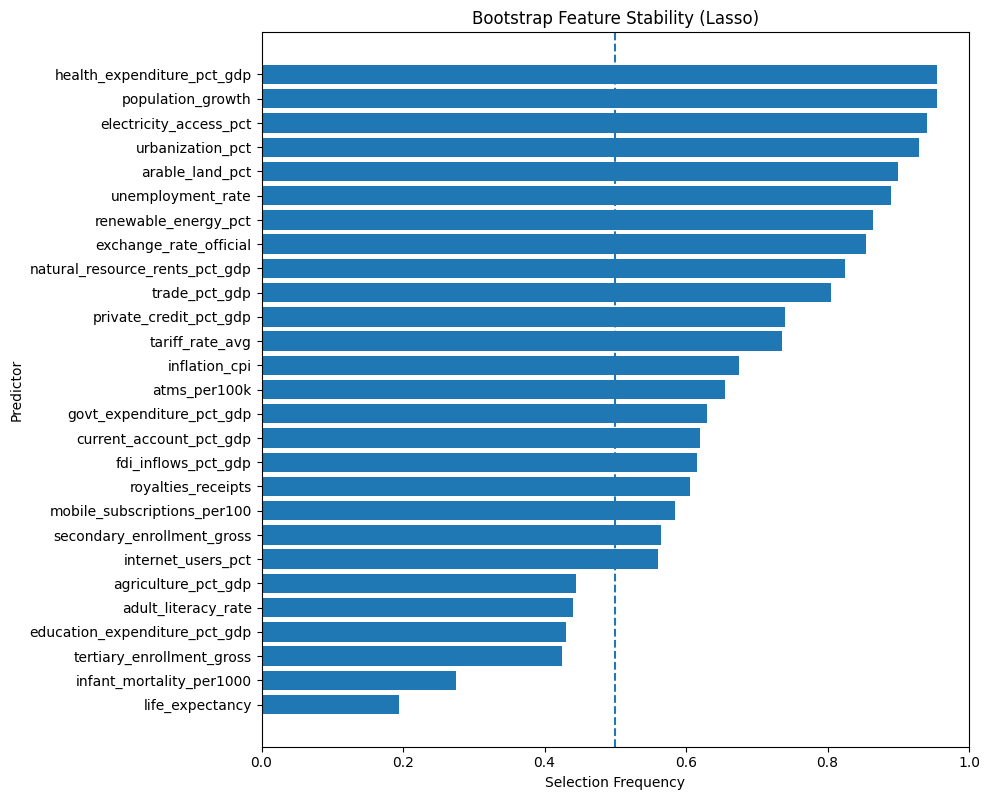

In [41]:
# ============================================================
# PART: Bootstrap Feature Stability for Lasso
# ============================================================

n_bootstraps = 200
coef_threshold = 1e-6
rng = np.random.default_rng(42)

# Use the predictor names from your original X matrix
feature_names = np.array(X.columns)

n_samples, n_features = X_train_scaled.shape

# Store 1 if selected, 0 if not selected
selection_matrix = np.zeros((n_bootstraps, n_features), dtype=int)

# Make sure y_train is a NumPy array for indexing
y_train_array = np.array(y_train)

for b in range(n_bootstraps):
    # Bootstrap sample indices
    bootstrap_idx = rng.choice(n_samples, size=n_samples, replace=True)

    # Resampled training data
    X_boot = X_train_scaled[bootstrap_idx]
    y_boot = y_train_array[bootstrap_idx]

    # Fit LassoCV on bootstrap sample
    lasso_boot = LassoCV(
        alphas=np.logspace(-4, 1, 100),
        cv=5,
        max_iter=10000,
        random_state=42
    )
    lasso_boot.fit(X_boot, y_boot)

    # Record whether each coefficient is non-zero
    selected = (np.abs(lasso_boot.coef_) > coef_threshold).astype(int)
    selection_matrix[b, :] = selected

# Compute selection frequency
selection_freq = selection_matrix.mean(axis=0)

# Create results table
stability_df = pd.DataFrame({
    "Feature": feature_names,
    "Selection Frequency": selection_freq
}).sort_values(by="Selection Frequency", ascending=False).reset_index(drop=True)

print(stability_df)

# Plot horizontal bar chart
plt.figure(figsize=(10, max(6, len(stability_df) * 0.3)))
plt.barh(stability_df["Feature"], stability_df["Selection Frequency"])
plt.axvline(x=0.5, linestyle='--')
plt.xlim(0, 1)
plt.xlabel("Selection Frequency")
plt.ylabel("Predictor")
plt.title("Bootstrap Feature Stability (Lasso)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The stable predictors, those selected more than 80% of the time, include health expenditure, population growth, electricity access, urbanization, and arable land, all of which show up consistently across samples. On the other end, fragile predictors like infant mortality and life expectancy fall below the 30% threshold, getting picked inconsistently depending on the specific sample drawn.

That instability points to a bigger issue: a lot of WDI indicators are highly correlated, so similar variables can effectively stand in for each other. When that happens, Lasso might pick one variable in one sample and swap it out for a closely related one in the next, rather than locking in a single clearly dominant predictor.

In Phase 3, I picked a threshold based on the IMF's 5-mission cap, but that ignores the financial weight of different mistakes. Missing a crisis runs about $50 billion in costs, while a false alarm is only around $2 million. So instead of optimizing for F1 or accuracy, I want to find the threshold that minimizes total expected cost.

Write a Python script that sweeps thresholds from 0.01 to 0.99 in steps of 0.01. At each threshold, convert the predicted probabilities into binary predictions, pull the false negative and false positive counts, and compute total cost using FN × 50,000,000,000 + FP × 2,000,000. Track costs across all thresholds and identify the one that minimizes total cost.

Assume `y_test_cls` and `y_prob` already exist. Loop using `np.arange(0.01, 1.00, 0.01)`, generate predictions with `(y_prob >= tau).astype(int)`, and use a confusion matrix to get FN and FP at each step. After the loop, pull the optimal threshold and its cost.

Print the cost-minimizing threshold and the minimum total cost, then plot total expected cost against threshold with a vertical line marking the optimal τ. Title it "Cost-Sensitive Threshold Optimization." Keep the code clean and runnable from start to finish.

Cost-minimizing threshold (τ): 0.04
Minimum total expected cost:   $68,000,000


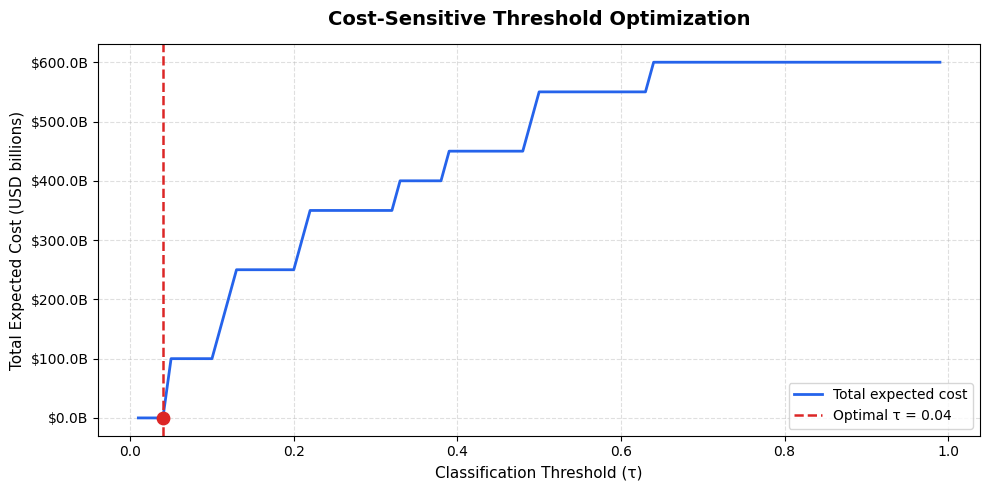

Plot saved.


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


np.random.seed(42)
y_prob = logit.predict_proba(X_test_sel_scaled)[:, 1]

# ─────────────────────────────────────────────────────────────────────────────

# Cost parameters
COST_FN = 50_000_000_000   # $50 billion  – missed crisis
COST_FP =      2_000_000   # $2 million   – false alarm

thresholds = np.arange(0.01, 1.00, 0.01)
costs      = []

for tau in thresholds:
    y_pred = (y_prob >= tau).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test_cls, y_pred, labels=[0, 1]).ravel()

    total_cost = fn * COST_FN + fp * COST_FP
    costs.append(total_cost)

costs = np.array(costs)

# ── Optimal threshold ─────────────────────────────────────────────────────────
optimal_idx       = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
minimum_cost      = costs[optimal_idx]

print(f"Cost-minimizing threshold (τ): {optimal_threshold:.2f}")
print(f"Minimum total expected cost:   ${minimum_cost:,.0f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds, costs / 1e9, color="#2563EB", linewidth=2, label="Total expected cost")
ax.axvline(optimal_threshold, color="#DC2626", linestyle="--", linewidth=1.8,
           label=f"Optimal τ = {optimal_threshold:.2f}")
ax.scatter([optimal_threshold], [minimum_cost / 1e9],
           color="#DC2626", zorder=5, s=80)

ax.set_title("Cost-Sensitive Threshold Optimization", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Classification Threshold (τ)", fontsize=11)
ax.set_ylabel("Total Expected Cost (USD billions)", fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.1f}B"))
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("cost_threshold_optimization.png", dpi=150)
plt.show()
print("Plot saved.")

The cost-minimizing threshold comes in lower than both the F1-optimal and capacity-constrained thresholds because missing a crisis carries such a steep price tag. F1 splits the difference between false positives and false negatives, and the capacity threshold just puts a ceiling on how many cases get flagged, but neither one actually reflects how lopsided the costs are. I would go with the cost-minimizing threshold since it is the only one that is grounded in real economic consequences and built around avoiding the mistakes that hurt most.